In [1]:
import geopandas as gpd

import matplotlib.pyplot as plt

from pathlib import Path

current_path = Path.cwd().parent
print(current_path)

/home/nissim/Documents/dev/ciut-inundaciones


In [2]:
dat = gpd.read_file(
    "/home/nissim/Documents/dev/ciut-inundaciones/data/combined_hazard_prioritized.geojson"
)

<Axes: >

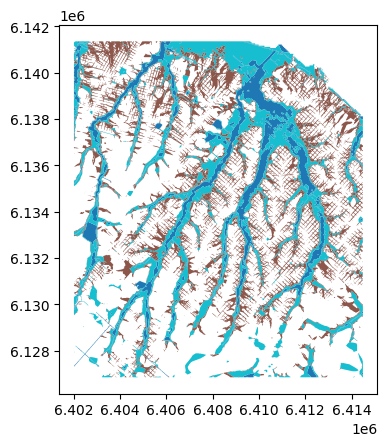

In [4]:
dat.plot("peligrosid")

In [6]:
import rasterio
from rasterio import features
import numpy as np
from shapely.geometry import shape

# Define the target raster properties
bounds = dat.total_bounds  # (minx, miny, maxx, maxy)
resolution = 10  # meters - adjust as needed
width = int((bounds[2] - bounds[0]) / resolution)
height = int((bounds[3] - bounds[1]) / resolution)

# Create a mapping from peligrosid values to numeric codes
peligrosid_mapping = {"alta": 3, "media": 2, "baja": 1}

# Create the raster
raster = np.zeros((height, width), dtype=np.uint8)

# Get the transform - corrected function call
transform = rasterio.transform.from_bounds(
    west=bounds[0],
    south=bounds[1],
    east=bounds[2],
    north=bounds[3],
    width=width,
    height=height,
)

# Rasterize the polygons
shapes = (
    (shape(geom), peligrosid_mapping.get(val, 0))
    for geom, val in zip(dat.geometry, dat["peligrosid"])
)

rasterized = features.rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,  # Fill nodata areas with 0
    dtype=np.uint8,
)

In [7]:
rasterized.plot()

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

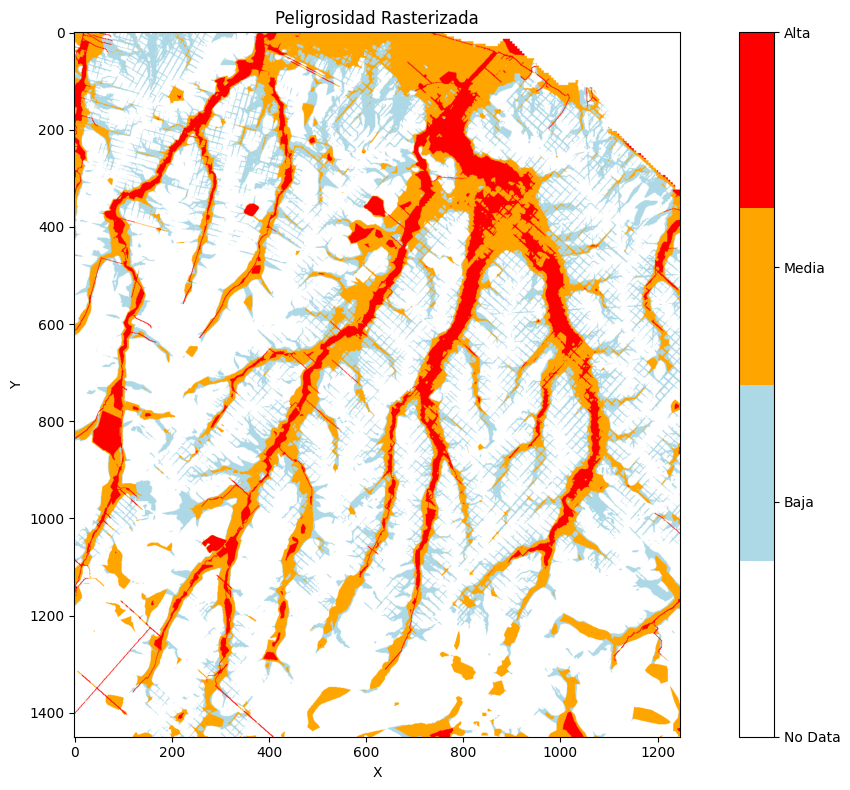

Raster shape: (1450, 1247)
Unique values: [0 1 2 3]
Value counts:
  No Data: 1117825 pixels
  Baja: 276532 pixels
  Media: 292673 pixels
  Alta: 121120 pixels


In [8]:
from matplotlib.colors import ListedColormap

# Create a custom colormap
colors = ["white", "lightblue", "orange", "red"]  # 0, 1, 2, 3
cmap = ListedColormap(colors)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
im = ax.imshow(rasterized, cmap=cmap, vmin=0, vmax=3)

# Add colorbar with labels
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
cbar.set_ticklabels(["No Data", "Baja", "Media", "Alta"])

ax.set_title("Peligrosidad Rasterizada")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.tight_layout()
plt.show()

# Print some stats
print(f"Raster shape: {rasterized.shape}")
print(f"Unique values: {np.unique(rasterized)}")
print("Value counts:")
for val, label in [(0, "No Data"), (1, "Baja"), (2, "Media"), (3, "Alta")]:
    count = np.sum(rasterized == val)
    print(f"  {label}: {count} pixels")

In [10]:
# Save the raster
with rasterio.open(
    "peligrosid_rasterized.tif",
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype=np.uint8,
    crs=dat.crs,
    transform=transform,
    nodata=0,
) as dst:
    dst.write(rasterized, 1)

print("Raster saved as 'peligrosid_rasterized.tif'")
print(f"Shape: {rasterized.shape}")
print(f"Unique values: {np.unique(rasterized)}")

Raster saved as 'peligrosid_rasterized.tif'
Shape: (1450, 1247)
Unique values: [0 1 2 3]


In [11]:
gdf = gpd.read_file(
    "/home/nissim/Documents/dev/ciut-inundaciones/src/finer_contours.geojson"
)

In [12]:
gdf = gdf[gdf["DN"] == 1]

<Axes: >

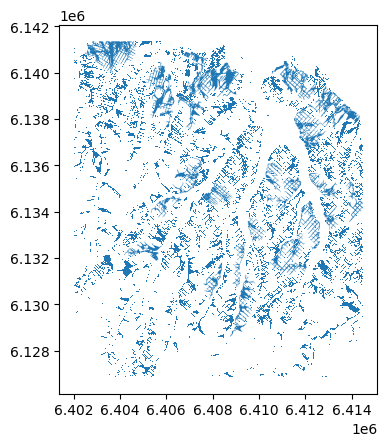

In [13]:
gdf.plot()

In [14]:
gdf.to_file(
    "/home/nissim/Documents/dev/ciut-inundaciones/src/finer_contours_baja.geojson",
    driver="GeoJSON",
)